## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Pengaturan visualisasi
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')

## Load & Siapkan Seluruh Data Historis 
Muat data bulanan penuh dari monthly_aggregated.csv dan tetapkan variabel target serta eksogennya (dari 03)

In [2]:
# Load data
df_m = pd.read_csv('dataset/monthly_aggregated.csv', parse_dates=['time'], index_col='time')
df_m.index.freq = 'MS'

# Definisikan kolom target dan eksogen
TARGETS = ['temperature_2m_mean', 'precipitation_sum', 'soil_moisture_0_7cm_mean', 'soil_temperature_0_7cm_mean']
EXOG = ['relative_humidity_2m_mean', 'sunshine_duration', 'precipitation_hours', 'cloud_cover_mean']

# Split train/test SAMA seperti notebook 03: latih sampai 2015, ramal mulai 2016
SPLIT_DATE = '2016-01-01'
train = df_m.loc[:'2015-12-31']
test  = df_m.loc[SPLIT_DATE:]   # aktual 2016-2025 (untuk validasi visual)

# Horizon ramalan: 2016-01 s.d 2027-03 (135 bulan = 120 validasi + 15 proyeksi).
# Catatan: proyeksi sengaja diperpanjang 3 bulan ke 2027-Q1 sebagai BUFFER untuk
# analisis siklus tanam 4-bulanan di notebook 05 — supaya bulan mulai-tanam s.d
# Desember 2026 punya data 4 bulan ke depan yang lengkap (Des-2026 -> Mar-2027).
FORECAST_INDEX = pd.date_range(start='2016-01-01', end='2027-03-01', freq='MS')

print(f'Train : {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} bulan)')
print(f'Aktual test : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} bulan)')
print(f'Horizon ramal: {FORECAST_INDEX.min().date()} -> {FORECAST_INDEX.max().date()}  ({len(FORECAST_INDEX)} bulan)')

Train : 1940-01-01 -> 2015-12-01  (912 bulan)
Aktual test : 2016-01-01 -> 2025-12-01  (120 bulan)
Horizon ramal: 2016-01-01 -> 2027-03-01  (135 bulan)


## Standardisasi Variabel Eksogen (fit di Train ≤2015)
Hitung mean & std eksogen **hanya dari data train (≤2015)** lalu pakai untuk standardisasi — sama seperti notebook 03, supaya tidak ada kebocoran informasi dari periode test 2016–2025.

In [3]:
# Statistik eksogen fit di TRAIN (≤2015) saja — mirror notebook 03
exog_mean = train[EXOG].mean()
exog_std  = train[EXOG].std()

# Standardisasi eksogen train (untuk fit model)
exog_train = (train[EXOG] - exog_mean) / exog_std

## Penyusunan Eksogen untuk Horizon Ramalan 2016–2027Q1
Model dilatih hanya sampai 2015, sehingga eksogen 135 bulan ke depan harus disediakan untuk `get_forecast`:
- **2016–2025 (120 bulan):** pakai **eksogen aktual** (observasi nyata) — adil untuk validasi vs aktual, persis seperti `exog_test` di notebook 03.
- **2026 + buffer s.d Mar-2027 (15 bulan):** **ekstrapolasi tren** linier per-(bulan, variabel) yang difit pada data **1990–2015 saja** (tanpa kebocoran info pasca-2015), lalu di-*clip* ke rentang fisik. 3 bulan terakhir (Jan–Mar 2027) hanya buffer siklus tanam, bukan fokus proyeksi.

Seluruh eksogen distandardisasi memakai statistik train (≤2015) yang sama.

In [4]:
# --- Bagian 1: eksogen AKTUAL 2016-2025 (observasi nyata) ---
obs_exog = df_m.loc['2016-01-01':'2025-12-01', EXOG]

# --- Bagian 2: eksogen TREN-ekstrapolasi 2026 + buffer s.d Mar-2027 ---
# Fit tren linier (nilai ~ tahun) per (bulan, variabel) HANYA pada 1990-2015 (tanpa leakage)
TREND_FIT_START, TREND_FIT_END = '1990-01-01', '2015-12-31'
hist_trend  = df_m.loc[TREND_FIT_START:TREND_FIT_END, EXOG]
hist_years  = hist_trend.index.year.values
hist_months = hist_trend.index.month.values

trend_params = {}  # (month, col) -> (slope, intercept)
for m in range(1, 13):
    mask = hist_months == m
    yrs  = hist_years[mask]
    for col in EXOG:
        slope, intercept = np.polyfit(yrs, hist_trend[col].values[mask], 1)
        trend_params[(m, col)] = (slope, intercept)

proj_index = pd.date_range(start='2026-01-01', end='2027-03-01', freq='MS')
proj_rows = [
    {col: trend_params[(d.month, col)][0] * d.year + trend_params[(d.month, col)][1]
     for col in EXOG}
    for d in proj_index
]
proj_exog = pd.DataFrame(proj_rows, index=proj_index, columns=EXOG)

# Guard rails: jaga nilai ekstrapolasi tetap dalam rentang fisik
proj_exog['precipitation_hours']         = proj_exog['precipitation_hours'].clip(lower=0)
proj_exog['sunshine_duration']           = proj_exog['sunshine_duration'].clip(lower=0)
proj_exog['relative_humidity_2m_mean']   = proj_exog['relative_humidity_2m_mean'].clip(0, 100)
proj_exog['cloud_cover_mean']            = proj_exog['cloud_cover_mean'].clip(0, 100)

# --- Gabung & standardisasi pakai statistik train (≤2015) ---
df_forecast_exog = pd.concat([obs_exog, proj_exog])
assert df_forecast_exog.index.equals(FORECAST_INDEX), 'Index eksogen ramalan tidak cocok 135 bulan'
exog_forecast_scaled = (df_forecast_exog - exog_mean) / exog_std

print(f'Eksogen ramalan: {df_forecast_exog.shape[0]} bulan  '
      f'({obs_exog.shape[0]} aktual + {proj_exog.shape[0]} tren)')

Eksogen ramalan: 135 bulan  (120 aktual + 15 tren)


## Latih Model SARIMAX (Train ≤2015)
Latih SARIMAX tiap target pada data train **1940–2015** dengan ordo yang sudah ditetapkan di notebook 03. `maxiter=200` untuk kestabilan konvergensi.

In [5]:
ORDERS = {
    'temperature_2m_mean':          ((1, 1, 4), (1, 1, 1, 12)),
    'precipitation_sum':             ((0, 1, 1), (0, 1, 1, 12)),
    'soil_moisture_0_7cm_mean':     ((1, 0, 2), (1, 1, 1, 12)),
    'soil_temperature_0_7cm_mean':  ((2, 1, 4), (2, 1, 0, 12)),
}

final_fits = {}

for col, (order, sorder) in ORDERS.items():
    print(f"Melatih model (train ≤2015) untuk: {col}...")
    y_train = train[col].loc[exog_train.index]   # selaraskan endog ke index exog train
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_fits[col] = model.fit(disp=False, maxiter=200)
    print(f"-> Model {col} BERHASIL dilatih!")

Melatih model (train ≤2015) untuk: temperature_2m_mean...
-> Model temperature_2m_mean BERHASIL dilatih!
Melatih model (train ≤2015) untuk: precipitation_sum...
-> Model precipitation_sum BERHASIL dilatih!
Melatih model (train ≤2015) untuk: soil_moisture_0_7cm_mean...
-> Model soil_moisture_0_7cm_mean BERHASIL dilatih!
Melatih model (train ≤2015) untuk: soil_temperature_0_7cm_mean...
-> Model soil_temperature_0_7cm_mean BERHASIL dilatih!


## Forecasting 2016–2026 & Evaluasi Overlap (2016–2025)
Ramal 132 bulan ke depan. Karena 2016–2025 punya nilai aktual, hitung metrik (RMSE/MAE/MAPE/R²) pada periode overlap tersebut untuk validasi — sisanya (2026) adalah proyeksi murni.

In [6]:
def _r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

df_forecast = pd.DataFrame(index=FORECAST_INDEX)
metrics = []

for col in TARGETS:
    # Ramal 135 bulan (2016-2027Q1, termasuk buffer siklus) dengan eksogen yang sudah disiapkan
    forecast_obj = final_fits[col].get_forecast(steps=len(FORECAST_INDEX), exog=exog_forecast_scaled)

    df_forecast[col] = forecast_obj.predicted_mean.values
    conf_int = forecast_obj.conf_int(alpha=0.05)
    df_forecast[f'{col}_lower'] = conf_int.iloc[:, 0].values
    df_forecast[f'{col}_upper'] = conf_int.iloc[:, 1].values

    # Evaluasi pada overlap aktual 2016-2025
    y_true = test[col].loc['2016-01-01':'2025-12-01']
    y_pred = df_forecast[col].loc[y_true.index]
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    mae  = (y_true - y_pred).abs().mean()
    mape = (y_true - y_pred).abs().div(y_true.abs().replace(0, np.nan)).mean() * 100
    metrics.append({'Target': col, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
                    'MAPE': f'{mape:.2f}%', 'R2': round(_r2(y_true, y_pred), 4)})

print("Forecasting 2016-2027Q1 selesai. Metrik validasi pada overlap 2016-2025:")
metrics_df = pd.DataFrame(metrics).set_index('Target')
metrics_df

Forecasting 2016-2027Q1 selesai. Metrik validasi pada overlap 2016-2025:


,RMSE,MAE,MAPE,R2
Target,,,,
temperature_2m_mean,0.335,0.266,1.03%,0.7874
precipitation_sum,46.615,33.977,19.30%,0.8570
soil_moisture_0_7cm_mean,0.048,0.037,9.32%,0.5714
soil_temperature_0_7cm_mean,0.657,0.535,1.95%,0.7058


In [7]:
# Ekspor hasil peramalan iklim 2016-2026 ke CSV dengan label indeks 'time'
OUT_CSV = 'dataset/forecasted_climate_2016_2026.csv'
df_forecast.to_csv(OUT_CSV, index=True, index_label='time')
print(f"Data ramalan 2016-2026 berhasil disimpan ke '{OUT_CSV}'!")

Data ramalan 2016-2026 berhasil disimpan ke 'dataset/forecasted_climate_2016_2026.csv'!


## Visualiasi

Grafik berhasil diekspor ke: images/report/forecast_summary_2016_2026.png


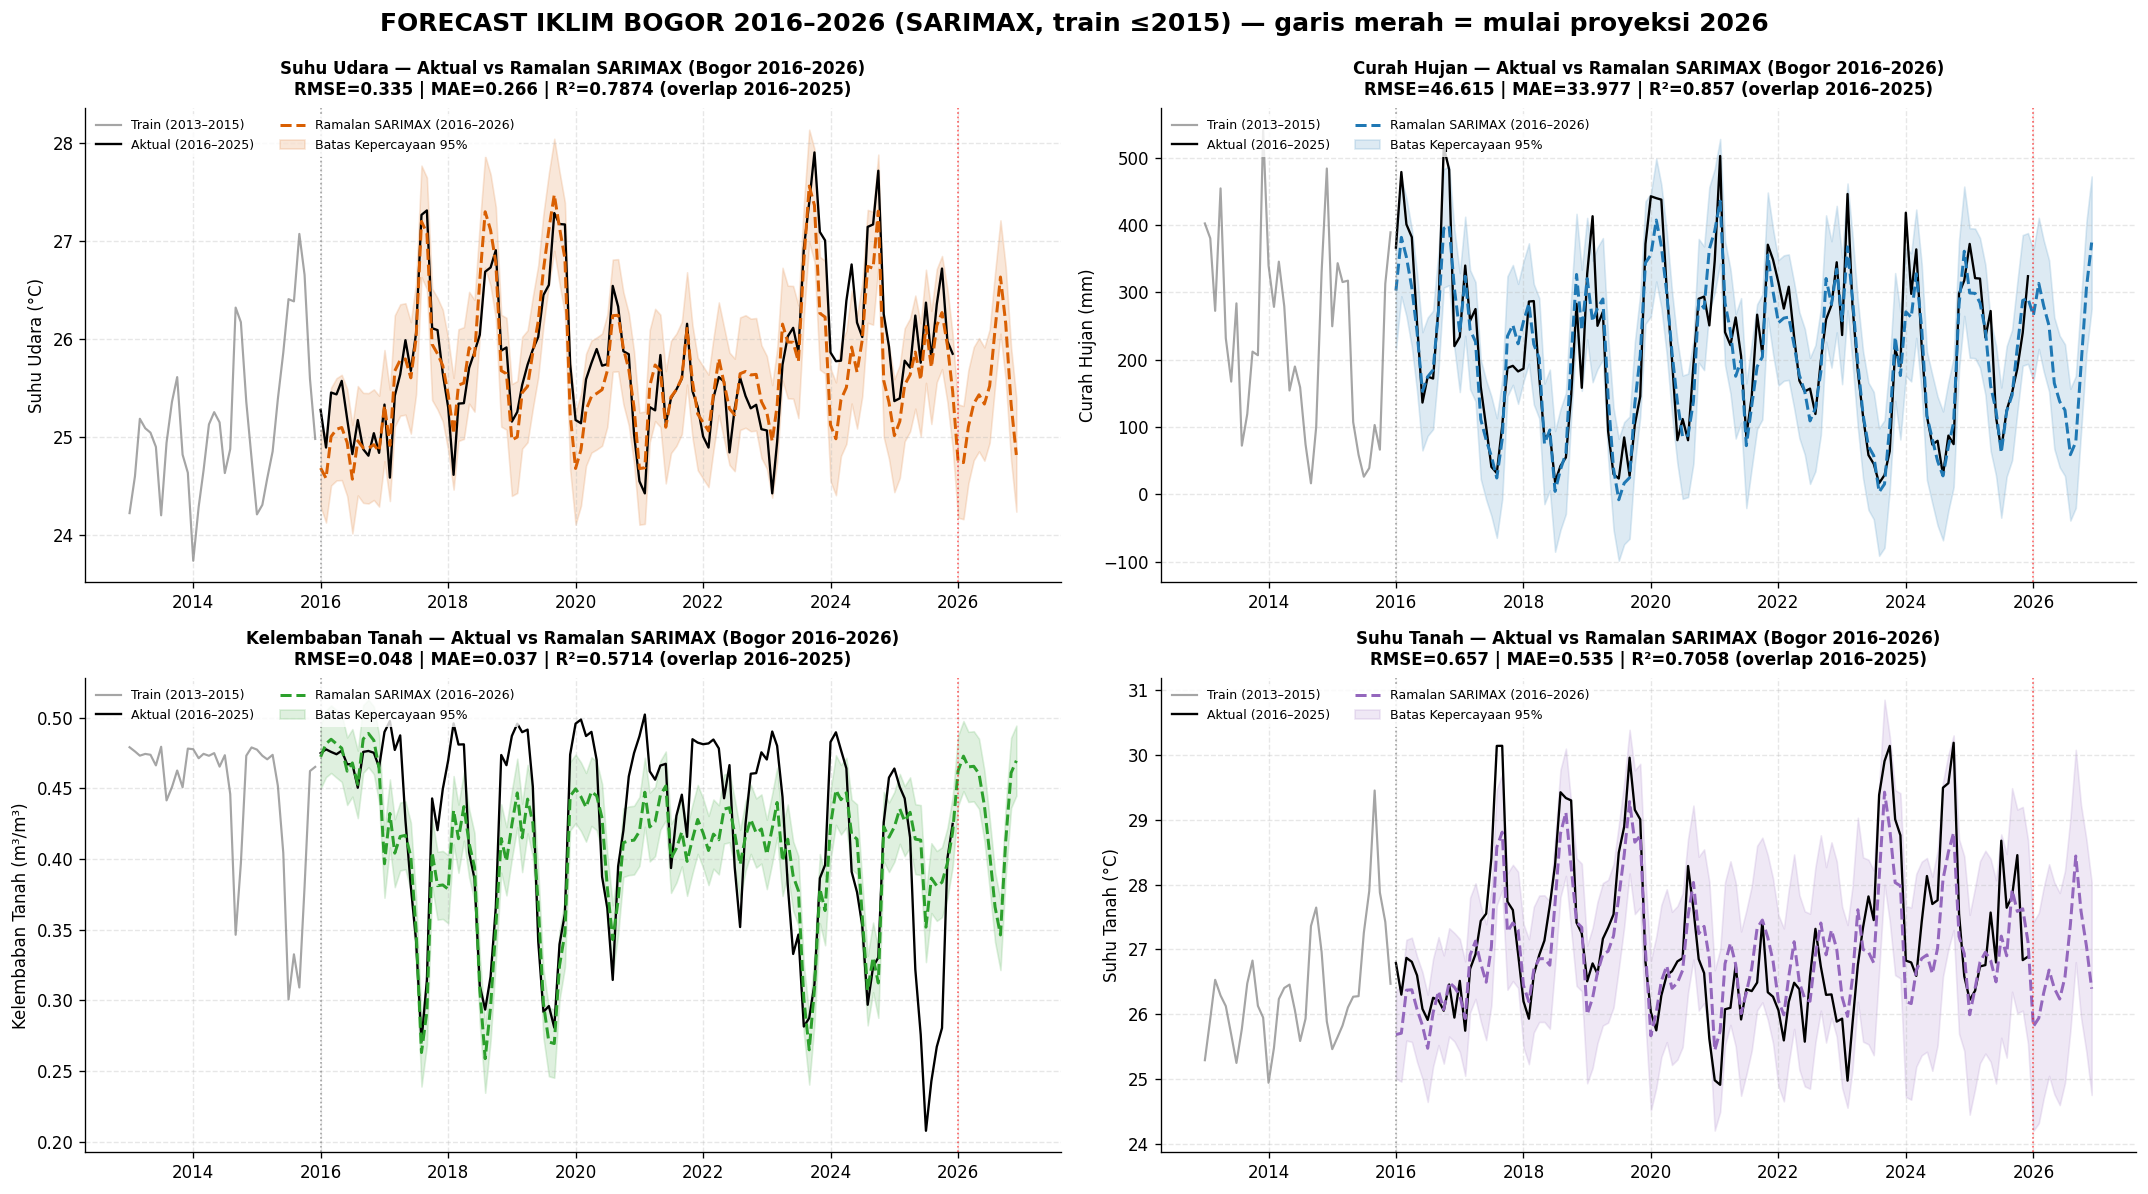

In [8]:
import os

# Konfigurasi Grid Visualisasi 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# Gaya visual per target
visual_styles = {
    'temperature_2m_mean': {
        'title': 'Suhu Udara — Aktual vs Ramalan SARIMAX (Bogor 2016–2026)',
        'ylabel': 'Suhu Udara (°C)', 'color': '#d95f02'},
    'precipitation_sum': {
        'title': 'Curah Hujan — Aktual vs Ramalan SARIMAX (Bogor 2016–2026)',
        'ylabel': 'Curah Hujan (mm)', 'color': '#1f78b4'},
    'soil_moisture_0_7cm_mean': {
        'title': 'Kelembaban Tanah — Aktual vs Ramalan SARIMAX (Bogor 2016–2026)',
        'ylabel': 'Kelembaban Tanah (m³/m³)', 'color': '#2ca02c'},
    'soil_temperature_0_7cm_mean': {
        'title': 'Suhu Tanah — Aktual vs Ramalan SARIMAX (Bogor 2016–2026)',
        'ylabel': 'Suhu Tanah (°C)', 'color': '#9467bd'},
}

PLOT_START = '2013-01-01'
PLOT_END   = '2026-12-01'   # sembunyikan buffer Q1-2027; fokus tampilan s.d Des 2026
df_plot = df_forecast.loc[:PLOT_END]
metrics_by_target = {m['Target']: m for m in metrics}

for idx, col in enumerate(TARGETS):
    ax = axes[idx]
    style = visual_styles[col]

    # Train tail (2013-2015) + aktual test (2016-2025)
    ax.plot(train[col].loc[PLOT_START:].index, train[col].loc[PLOT_START:].values,
            color='#7f7f7f', lw=1.3, alpha=0.7, label='Train (2013–2015)')
    ax.plot(test[col].loc[:'2025-12-01'].index, test[col].loc[:'2025-12-01'].values,
            color='black', lw=1.4, label='Aktual (2016–2025)')

    # Ramalan SARIMAX 2016-2026
    ax.plot(df_plot.index, df_plot[col].values,
            color=style['color'], lw=1.8, linestyle='--', label='Ramalan SARIMAX (2016–2026)')
    ax.fill_between(df_plot.index, df_plot[f'{col}_lower'], df_plot[f'{col}_upper'],
                    color=style['color'], alpha=0.15, label='Batas Kepercayaan 95%')

    # Garis penanda: mulai ramal (2016) & mulai proyeksi murni (2026)
    ax.axvline(pd.Timestamp('2016-01-01'), color='gray', lw=1, ls=':', alpha=0.7)
    ax.axvline(pd.Timestamp('2026-01-01'), color='red',  lw=1, ls=':', alpha=0.6)

    m = metrics_by_target[col]
    ax.set_title(f"{style['title']}\nRMSE={m['RMSE']} | MAE={m['MAE']} | R²={m['R2']} (overlap 2016–2025)",
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel(style['ylabel'], fontsize=10)
    ax.legend(loc='upper left', fontsize=7.5, ncol=2, frameon=True, facecolor='white', edgecolor='none')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('FORECAST IKLIM BOGOR 2016–2026 (SARIMAX, train ≤2015) — garis merah = mulai proyeksi 2026',
             fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()

# Ekspor grafik
output_dir = 'images/report'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'forecast_summary_2016_2026.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Grafik berhasil diekspor ke: {output_path}")

plt.show()